# Ensemble: LeViT-128 + ResNet50
Same pattern as the other ensemble notebooks. Both models here take raw float32 [0, 255] pixel input (normalization is baked into each model's graph — LeViT via a Lambda torch-style normalization layer, ResNet50 via `preprocess_input`), so only ONE test dataset is needed.

Run cells top to bottom (or Runtime → Run all).

## Cell 1 — Setup (installs + imports)

In [1]:
!pip install -U keras-cv-attention-models tf_keras -q

import os
# IMPORTANT: must be set BEFORE importing tensorflow/keras.
# keras_cv_attention_models (LeViT) was written for Keras 2 style graph
# building and breaks under Keras 3's stricter KerasTensor rules
# ("A KerasTensor cannot be used as input to a TensorFlow function").
# Forcing legacy tf.keras avoids this without touching the library's code.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras_cv_attention_models import levit

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("All imports successful!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 31.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobu

## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set (images + CSV)

In [4]:
# Force remount Drive first (fixes "Transport endpoint is not connected")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Mounted at /content/drive
Test folder ready: True


## Cell 4 — Load test CSV, fix paths
This defines `class_names`, `label_to_index`, `true_labels` — required by later cells.

In [5]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(test_df['filepath'].iloc[0]))
print("Test samples:", len(test_df))

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

print("Classes:", class_names)

Sample file exists: True
Test samples: 2538
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 5 — Config

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

## Cell 6 — Build the loading function
Both LeViT-128 (torch-style normalization via a Lambda layer inside the model) and ResNet50 (`preprocess_input` baked into the model) expect raw float32 pixel values in the [0, 255] range — so a single loader/dataset covers both models here.

In [7]:
def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img  # stays float32, values 0-255

## Cell 7 — Build the test dataset

In [8]:
def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_float32 = make_ds(load_float32)  # used for both LeViT-128 and ResNet50

print("Dataset ready")

Dataset ready


## Cell 8 — Load both trained models
LeViT-128 is rebuilt from architecture exactly as in training, then `load_weights`. ResNet50 is loaded from a zip backup on Drive.

In [9]:
# --- LeViT-128: rebuild architecture exactly as in training, then load trained weights ---
levit_backbone = levit.LeViT128(input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet")
levit_backbone.trainable = False

levit_inputs = layers.Input(shape=(224, 224, 3), dtype='float32')

# torch-style normalization (matches training notebook exactly)
# FIX: Keras 3 does not allow a raw TF op on a KerasTensor via a Lambda that
# closes over external tf.constant tensors. Wrapping the operation in a proper
# Layer subclass (as suggested by the original error message) avoids the
# "KerasTensor cannot be used as input to a TensorFlow function" error.
class TorchNormalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406]) * 255.0
        self.std = tf.constant([0.229, 0.224, 0.225]) * 255.0

    def call(self, x):
        return (x - self.mean) / self.std

x = TorchNormalize()(levit_inputs)

x = levit_backbone(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
levit_outputs = layers.Dense(num_classes, activation='softmax')(x)

levit_model = models.Model(levit_inputs, levit_outputs)
levit_model.load_weights('/content/drive/MyDrive/thesis_levit_outputs/best_levit_model.keras')
print("LeViT-128 model rebuilt and weights loaded!")


37854624/37854624 [==============================] - 1s 0us/step
>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
LeViT-128 model rebuilt and weights loaded!


In [11]:
# --- ResNet50: rebuild architecture exactly as in training, then load weights only ---
resnet_zip_path = '/content/drive/MyDrive/thesis_resnet50_outputs-20260716T043630Z-1-001.zip'
print("Zip exists:", os.path.exists(resnet_zip_path))

if not os.path.exists('/content/resnet50_data'):
    with zipfile.ZipFile(resnet_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/resnet50_data')

resnet_model_path = '/content/resnet50_data/thesis_resnet50_outputs/best_resnet50_model.keras'
print("Model file exists:", os.path.exists(resnet_model_path))

# Extract the .weights.h5 file that lives inside the .keras archive
resnet_weights_extract_dir = '/content/resnet50_weights_extracted'
if not os.path.exists(resnet_weights_extract_dir):
    with zipfile.ZipFile(resnet_model_path, 'r') as zip_ref:
        zip_ref.extractall(resnet_weights_extract_dir)

resnet_weights_path = None
for root, dirs, files in os.walk(resnet_weights_extract_dir):
    for fname in files:
        if fname.endswith('.weights.h5') or fname == 'model.weights.h5':
            resnet_weights_path = os.path.join(root, fname)
            break
print("Weights file found:", resnet_weights_path)

# Rebuild the exact same architecture used in training (Resnet50.ipynb, Cell 5-6)
resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)

resnet_input = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(resnet_input)
x = resnet_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
resnet_output = layers.Dense(num_classes, activation='softmax')(x)

resnet_model = models.Model(resnet_input, resnet_output)
resnet_model.load_weights(resnet_weights_path)
print("ResNet50 rebuilt and weights loaded successfully")

Zip exists: True
Model file exists: True
Weights file found: /content/resnet50_weights_extracted/model.weights.h5
ResNet50 rebuilt and weights loaded successfully


## Cell 8b — Sanity check: both models still reproduce their known test accuracy

In [12]:
pred_levit_check = levit_model.predict(test_ds_float32, verbose=1)
acc_levit_check = accuracy_score(true_labels, np.argmax(pred_levit_check, axis=1))
print(f"LeViT-128 test accuracy (rebuilt model): {acc_levit_check:.4f}")

pred_resnet_check = resnet_model.predict(test_ds_float32, verbose=1)
acc_resnet_check = accuracy_score(true_labels, np.argmax(pred_resnet_check, axis=1))
print(f"ResNet50 test accuracy (reloaded model): {acc_resnet_check:.4f}")

80/80 [==============================] - 22s 140ms/step
LeViT-128 test accuracy (rebuilt model): 0.9515
80/80 [==============================] - 11s 107ms/step
ResNet50 test accuracy (reloaded model): 0.9795


## Cell 9 — Get predictions from each model (test set, reused for the ensemble below)

In [13]:
pred_levit = pred_levit_check    # already computed in the sanity check above
pred_resnet = pred_resnet_check  # already computed in the sanity check above

## Cell 10 — Ensemble (simple average) + accuracy comparison

In [14]:
ensemble_probs = (pred_levit + pred_resnet) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

pred_levit_labels = np.argmax(pred_levit, axis=1)
pred_resnet_labels = np.argmax(pred_resnet, axis=1)

acc_levit = accuracy_score(true_labels, pred_levit_labels)
acc_resnet = accuracy_score(true_labels, pred_resnet_labels)
acc_ensemble = accuracy_score(true_labels, ensemble_preds)

print("=" * 55)
print("RESULTS (Simple Average Ensemble)")
print("=" * 55)
print(f"LeViT-128 accuracy:          {acc_levit:.4f}")
print(f"ResNet50 accuracy:           {acc_resnet:.4f}")
print(f"Ensemble (avg) accuracy:     {acc_ensemble:.4f}")

RESULTS (Simple Average Ensemble)
LeViT-128 accuracy:          0.9515
ResNet50 accuracy:           0.9795
Ensemble (avg) accuracy:     0.9779


## Cell 11 — Val set predictions (needed for leakage-free weight tuning)

In [15]:
val_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
val_df['filepath'] = val_df['filepath'].str.replace('/content/split_dataset', '/content')

val_true_labels = val_df['label'].map(label_to_index).values
val_filepaths = val_df['filepath'].values

def make_ds_from_paths(paths, load_fn):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds_float32 = make_ds_from_paths(val_filepaths, load_float32)

print("Predicting on VAL set with LeViT-128...")
val_pred_levit = levit_model.predict(val_ds_float32, verbose=1)
print("Predicting on VAL set with ResNet50...")
val_pred_resnet = resnet_model.predict(val_ds_float32, verbose=1)

Predicting on VAL set with LeViT-128...
79/79 [==============================] - 11s 134ms/step
Predicting on VAL set with ResNet50...
79/79 [==============================] - 8s 101ms/step


## Cell 12 — Weighted ensemble (weights tuned on VAL set, evaluated once on TEST set — no leakage)

In [16]:
best_w, best_val_acc = (0.5, 0.5), accuracy_score(
    val_true_labels, np.argmax((val_pred_levit + val_pred_resnet) / 2.0, axis=1)
)

for w_levit in np.arange(0.1, 1.0, 0.05):
    w_resnet = 1 - w_levit
    val_probs = (w_levit * val_pred_levit) + (w_resnet * val_pred_resnet)
    val_acc = accuracy_score(val_true_labels, np.argmax(val_probs, axis=1))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_w = (round(w_levit, 2), round(w_resnet, 2))

print(f"Best weighted combo (found on VAL set): {best_w}")
print(f"Val accuracy with this combo: {best_val_acc:.4f}")

w_levit_final, w_resnet_final = best_w
test_probs_weighted = (w_levit_final * pred_levit) + (w_resnet_final * pred_resnet)
ensemble_preds_weighted = np.argmax(test_probs_weighted, axis=1)
acc_ensemble_weighted = accuracy_score(true_labels, ensemble_preds_weighted)

print(f"\nFinal TEST accuracy with tuned weights: {acc_ensemble_weighted:.4f}")

Best weighted combo (found on VAL set): (np.float64(0.35), np.float64(0.65))
Val accuracy with this combo: 0.9794

Final TEST accuracy with tuned weights: 0.9795


## Cell 13 — Classification report (using the simple-average ensemble predictions)

In [17]:
report = classification_report(true_labels, ensemble_preds, target_names=class_names)
print(report)

                            precision    recall  f1-score   support

          Corn_Common_Rust       1.00      0.97      0.99       197
       Corn_Gray_Leaf_Spot       0.94      0.93      0.93       177
              Corn_Healthy       0.99      1.00      1.00       175
          Corn_Leaf_Blight       0.92      0.95      0.93       173
Rice_Bacterial_Leaf_Blight       0.99      0.98      0.99       294
           Rice_Brown_Spot       1.00      0.97      0.99       271
              Rice_Healthy       0.98      0.99      0.99       331
           Rice_Leaf_Blast       0.96      0.98      0.97       257
          Wheat_Brown_Rust       0.97      0.99      0.98       184
             Wheat_Healthy       0.99      0.98      0.99       207
          Wheat_Loose_Smut       0.99      1.00      0.99        80
         Wheat_Yellow_Rust       0.99      0.98      0.98       192

                  accuracy                           0.98      2538
                 macro avg       0.98      0.9

## Cell 14 — Confusion matrix + save everything to Drive

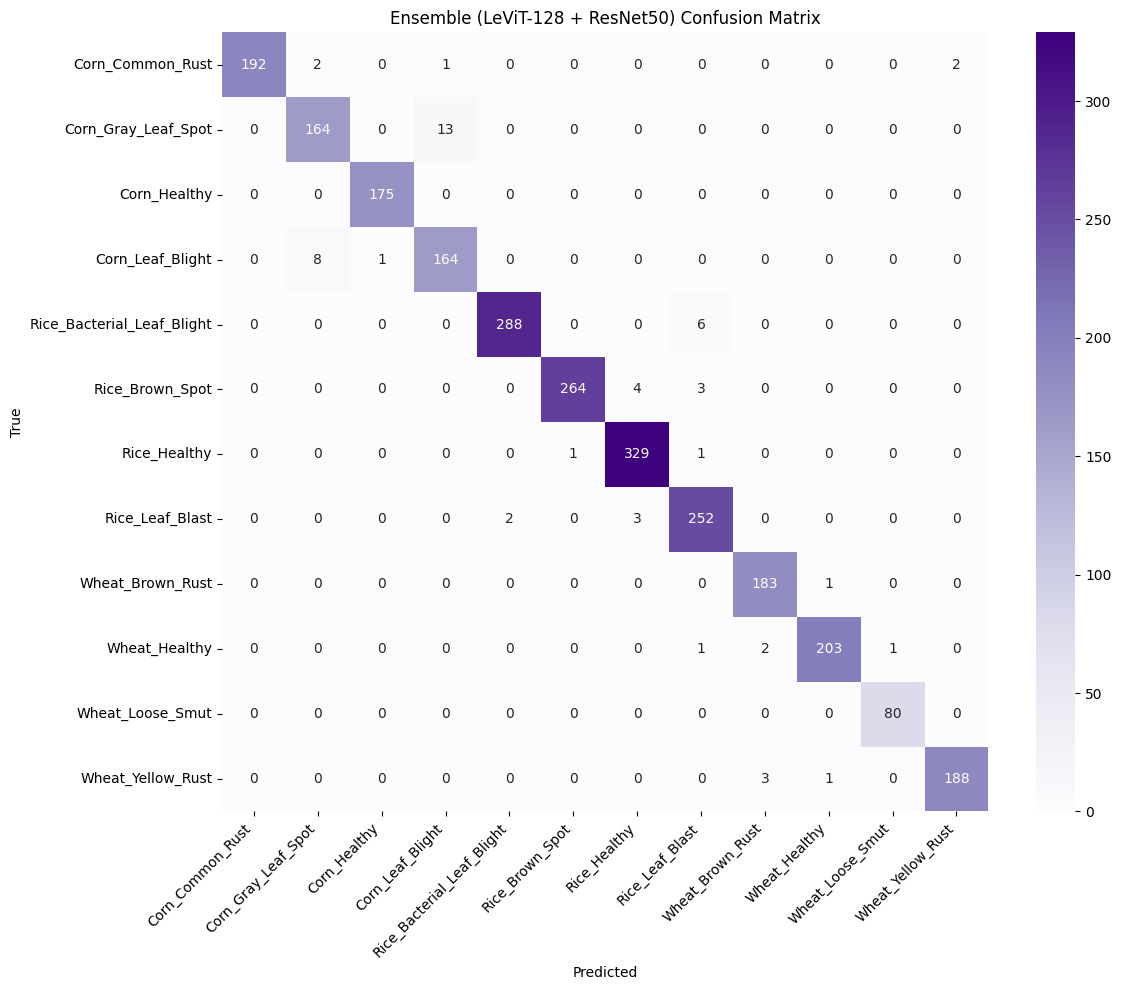

Results saved to: /content/drive/MyDrive/thesis_ensemble_outputs


In [18]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)

with open(f'{output_folder}/ensemble_levit_resnet50_report.txt', 'w') as f:
    f.write(f"LeViT-128 accuracy: {acc_levit:.4f}\n")
    f.write(f"ResNet50 accuracy: {acc_resnet:.4f}\n")
    f.write(f"Ensemble (simple average) accuracy: {acc_ensemble:.4f}\n")
    f.write(f"Best weighted combo (tuned on val set): {best_w}\n")
    f.write(f"Ensemble (weighted) test accuracy: {acc_ensemble_weighted:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(true_labels, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Ensemble (LeViT-128 + ResNet50) Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_folder}/ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {output_folder}")